In [1]:
if !@isdefined(CBOFSData)
    println("Loading modules and packages...")
    include("../src/cbdata.jl")
    include("../src/ASVGeometry.jl")
    include("../src/clarity.jl")
    include("../src/IVESim.jl")
    include("../src/ntfy.jl")

    using .CBOFSData, .ASVGeometry, .Clarity, .IVESim, .Notify
    using Dates, Statistics, Plots, JuMP, Ipopt, ProgressMeter, JLD2, DataFrames
    
    # Optional: If you are actively editing cbdata.jl, ASVGeometry.jl, etc. 
    # you can use Revise to automatically track changes without re-including!
    using Revise
end


Loading modules and packages...


In [2]:
# Plot Settings
plot_font = "Computer Modern"
default(
    fontfamily=plot_font,
    linewidth=2,
    guidefontsize=14,
    tickfontsize=14,
    legendfontsize=10,
    titlefontsize=18
)

In [3]:
frames = discover_files("./datafiles")

120-element Vector{CBOFSFrame}:
 CBOFSFrame("./datafiles\\chesapeake_salinity_20260216_t00z_n001.nc", DateTime("2026-02-16T01:00:00"))
 CBOFSFrame("./datafiles\\chesapeake_salinity_20260216_t00z_n002.nc", DateTime("2026-02-16T02:00:00"))
 CBOFSFrame("./datafiles\\chesapeake_salinity_20260216_t00z_n003.nc", DateTime("2026-02-16T03:00:00"))
 CBOFSFrame("./datafiles\\chesapeake_salinity_20260216_t00z_n004.nc", DateTime("2026-02-16T04:00:00"))
 CBOFSFrame("./datafiles\\chesapeake_salinity_20260216_t00z_n005.nc", DateTime("2026-02-16T05:00:00"))
 CBOFSFrame("./datafiles\\chesapeake_salinity_20260216_t00z_n006.nc", DateTime("2026-02-16T06:00:00"))
 CBOFSFrame("./datafiles\\chesapeake_salinity_20260216_t06z_n001.nc", DateTime("2026-02-16T07:00:00"))
 CBOFSFrame("./datafiles\\chesapeake_salinity_20260216_t06z_n002.nc", DateTime("2026-02-16T08:00:00"))
 CBOFSFrame("./datafiles\\chesapeake_salinity_20260216_t06z_n003.nc", DateTime("2026-02-16T09:00:00"))
 CBOFSFrame("./datafiles\\chesapeake_sali

In [49]:
# datafile = "2026-03-25_143945_cb_sim_results.jld2";
datafile = "2026-03-26_172847_static_sim_results.jld2"
# datafile = "2026-03-26_172952_const_speed_static_sim_results.jld2"
results = load(datafile)

Dict{String, Any} with 7 entries:
  "weights_history"    => [1.0 1.0 … 1.0 1.0; 1.0 1.0 … 1.0 1.0; … ; 1.0 1.0 … …
  "clarity_history"    => [0.965451 0.957457 … 1.63776e-17 1.54239e-17; 0.85127…
  "lap_hist"           => [1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  10, 10, 10, 10, 10,…
  "speed_hist"         => [3.49971, 3.49971, 3.49971, 3.49974, 3.49974, 3.49974…
  "salinity_meas_hist" => [32.4335, 32.5076, 32.5076, 32.5076, 32.7158, 32.7158…
  "lat_hist"           => [36.975, 36.9769, 36.9788, 36.9807, 36.9825, 36.9844,…
  "lon_hist"           => [-76.015, -76.015, -76.015, -76.015, -76.015, -76.015…

In [50]:
if haskey(results, "weights_history_const")
    weights_history = results["weights_history_const"];
    clarity_history = results["clarity_history_const"];
    lap_hist = results["lap_hist_const"];
    speed_hist = results["speed_hist_const"];
    salinity_meas_hist = results["salinity_meas_hist_const"];
    lat_hist = results["lat_hist_const"];
    lon_hist = results["lon_hist_const"];
    tag = "const_speed"
else
    weights_history = results["weights_history"];
    clarity_history = results["clarity_history"];
    lap_hist = results["lap_hist"];
    speed_hist = results["speed_hist"];
    salinity_meas_hist = results["salinity_meas_hist"];
    lat_hist = results["lat_hist"];
    lon_hist = results["lon_hist"];
    tag = "variable_speed"
end

"variable_speed"

In [51]:
total_clarity = sum(weights_history .* clarity_history)
println("Total Accumulated Clarity (All Time): ", round(total_clarity, digits=2))

total_laps = lap_hist[end]
lap_clarity = zeros(Float64, total_laps)

for lap in 1:total_laps
    idx_for_lap = findall(x -> x == lap, lap_hist)
    lap_clarity[lap] = sum(clarity_history[:, idx_for_lap])
    println("Lap $lap Total Clarity: ", round(lap_clarity[lap], digits=2))
end

target_salinity = 30.0
salinity_deviation = salinity_meas_hist .- target_salinity

println("Mean Salinity Deviation: ", round(mean(salinity_deviation), digits=2), " PSU")
println("Standard Deviation of Salinity Deviation: ", round(std(salinity_deviation), digits=2), " PSU")

Total Accumulated Clarity (All Time): 28704.58
Lap 1 Total Clarity: 4544.16
Lap 2 Total Clarity: 4626.24
Lap 3 Total Clarity: 4619.76
Lap 4 Total Clarity: 4619.86
Lap 5 Total Clarity: 4619.69
Lap 6 Total Clarity: 4626.88
Lap 7 Total Clarity: 4619.73
Lap 8 Total Clarity: 4619.89
Lap 9 Total Clarity: 4619.88
Lap 10 Total Clarity: 4154.53
Mean Salinity Deviation: -1.01 PSU
Standard Deviation of Salinity Deviation: 2.67 PSU


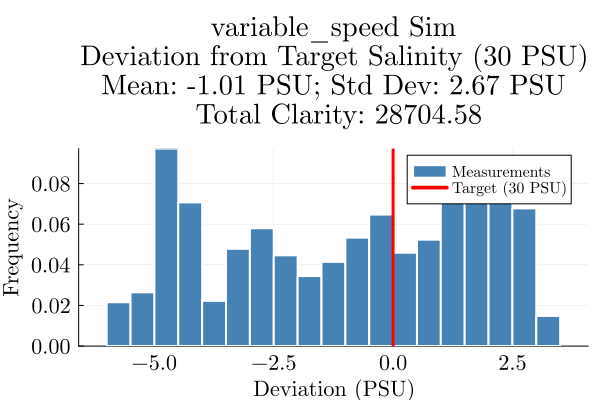

In [52]:
μ = mean(salinity_deviation)
σ = std(salinity_deviation)

stats_txt = "Mean: $(round(μ, digits=2)) PSU; Std Dev: $(round(σ, digits=2)) PSU\n Total Clarity: $(round(total_clarity, digits=2))"

p = histogram(
    salinity_deviation,
    bins = 30,
    normalize = :probability,
    title = "$(tag) Sim\nDeviation from Target Salinity (30 PSU)\n$stats_txt",
    xlabel = "Deviation (PSU)",
    ylabel = "Frequency",
    label = "Measurements",
    color = :steelblue,
    linecolor = :white,
    grid = true,
    topmargin = 15Plots.mm,
)

vline!(p, [0.0], lw = 3, color = :red, label = "Target (30 PSU)")
savefig(p, "temp_figs/$(tag)_salinity_deviation_histogram.png")
plot!()

In [53]:
frame_times = [fr.dt for fr in frames]
frame_idx_for_time(t) = argmin(abs.(Dates.value.(frame_times .- t)))

npts = size(clarity_history, 1)
lon_path, lat_path, s_vec = discretize_polyline(transect_lon_shifted, transect_lat_shifted, npts)
sim_times = collect(frames[1].dt : Minute(1) : frames[end].dt)
N_steps = length(sim_times)
nsteps = length(sim_times)
@assert nsteps > 0 "No simulation history found. Run the simulation cell first."

frame_stride = max(1, fld(nsteps, 300))
frame_ids = 1:frame_stride:nsteps

lat_min, lat_max = 36.75, 37.5
lon_pad, lat_pad = 0.02, 0.02
xlims_map = (minimum(lon_path) - lon_pad, maximum(lon_path) + lon_pad)
ylims_map = (lat_min - lat_pad, lat_max + lat_pad)

smin = minimum(salinity_meas_hist)
smax = maximum(salinity_meas_hist)
spad = max(0.5, 0.05 * max(smax - smin, eps()))
target_salinity = 30.0

sal_cache = Dict{String, Tuple{Vector{Float64}, Vector{Float64}, Vector{Float64}}}()

l = @layout [a b; c]

anim = @animate for k in frame_ids
    lon_r, lat_r = lon_hist[k], lat_hist[k]
    
    tr_lon = lon_hist[1:k]
    tr_lat = lat_hist[1:k]

    fr = frames[frame_idx_for_time(sim_times[k])]
    if !haskey(sal_cache, fr.file)
        sal_cache[fr.file] = load_surface_salinity(fr.file)
    end
    lon_v, lat_v, salt_v = sal_cache[fr.file]

    roi = (lon_v .>= xlims_map[1]) .& (lon_v .<= xlims_map[2]) .&
        (lat_v .>= ylims_map[1]) .& (lat_v .<= ylims_map[2])
    idx = findall(roi)
    
    if length(idx) > 12000
        step_val = cld(length(idx), 12000)
        idx = idx[1:step_val:end]
    end

    p1 = scatter(
        lon_v[idx], lat_v[idx];
        marker_z = salt_v[idx],
        m = (2.0, :square, stroke(0)),
        c = :viridis, clims = (0, 35),
        colorbar = true, colorbar_title = "Salinity (PSU)",
        xlabel = "Longitude", ylabel = "Latitude",
        title = "Boat + Salinity\n$(Dates.format(sim_times[k], dateformat"yyyy-mm-dd HH:MM")) UTC | Lap $(lap_hist[k])",
        aspect_ratio = :equal, xlims = xlims_map, ylims = ylims_map,
        framestyle = :box, grid = true, legend = :bottomleft
    )
    plot!(p1, transect_lon_shifted, transect_lat_shifted; lw = 2.5, lc = :white, label = "Planned Path")
    plot!(p1, tr_lon, tr_lat; lw = 2, lc = :dodgerblue, label = "Track")
    scatter!(p1, [lon_r], [lat_r]; ms = 6, mc = :red, label = "Boat")

    p2 = plot(
        lon_path, lat_path;
        line_z = clarity_history[:, k], 
        linewidth = 6, 
        c = :plasma, clims = (0, 1),
        colorbar = true, colorbar_title = "Clarity",
        xlabel = "Longitude", ylabel = "Latitude",
        title = "Clarity Map (Path Points)",
        aspect_ratio = :equal, xlims = xlims_map, ylims = ylims_map,
        legend = false, framestyle = :box, grid = true
    )
    
    scatter!(p2, [lon_r], [lat_r]; ms = 6, mc = :white, msw = 0, label = false)
    
    p3 = plot(
        sim_times[1:k], salinity_meas_hist[1:k];
        lw = 2.5, lc = :darkorange,
        xlabel = "Time", ylabel = "Measured Salinity (PSU)",
        title = "Measured Salinity vs Time",
        ylims = (smin - spad, smax + spad),
        xlims = (sim_times[1], sim_times[end]), 
        legend = :topright, framestyle = :box, grid = true,
        label = "Measured"
    )
    hline!(p3, [target_salinity]; lc = :red, ls = :dash, lw = 1.5, label = "Target")

    plot(p1, p2, p3; layout = l, size = (1400, 900))
end

mp4(anim, "test.mp4"; fps = 15)


[ Info: Saved animation to c:\Users\kavin\OneDrive\Research\CPS\cdc26_ive_intro\code\chesapeake_bay\test.mp4


Plots.AnimatedGif("c:\\Users\\kavin\\OneDrive\\Research\\CPS\\cdc26_ive_intro\\code\\chesapeake_bay\\test.mp4")

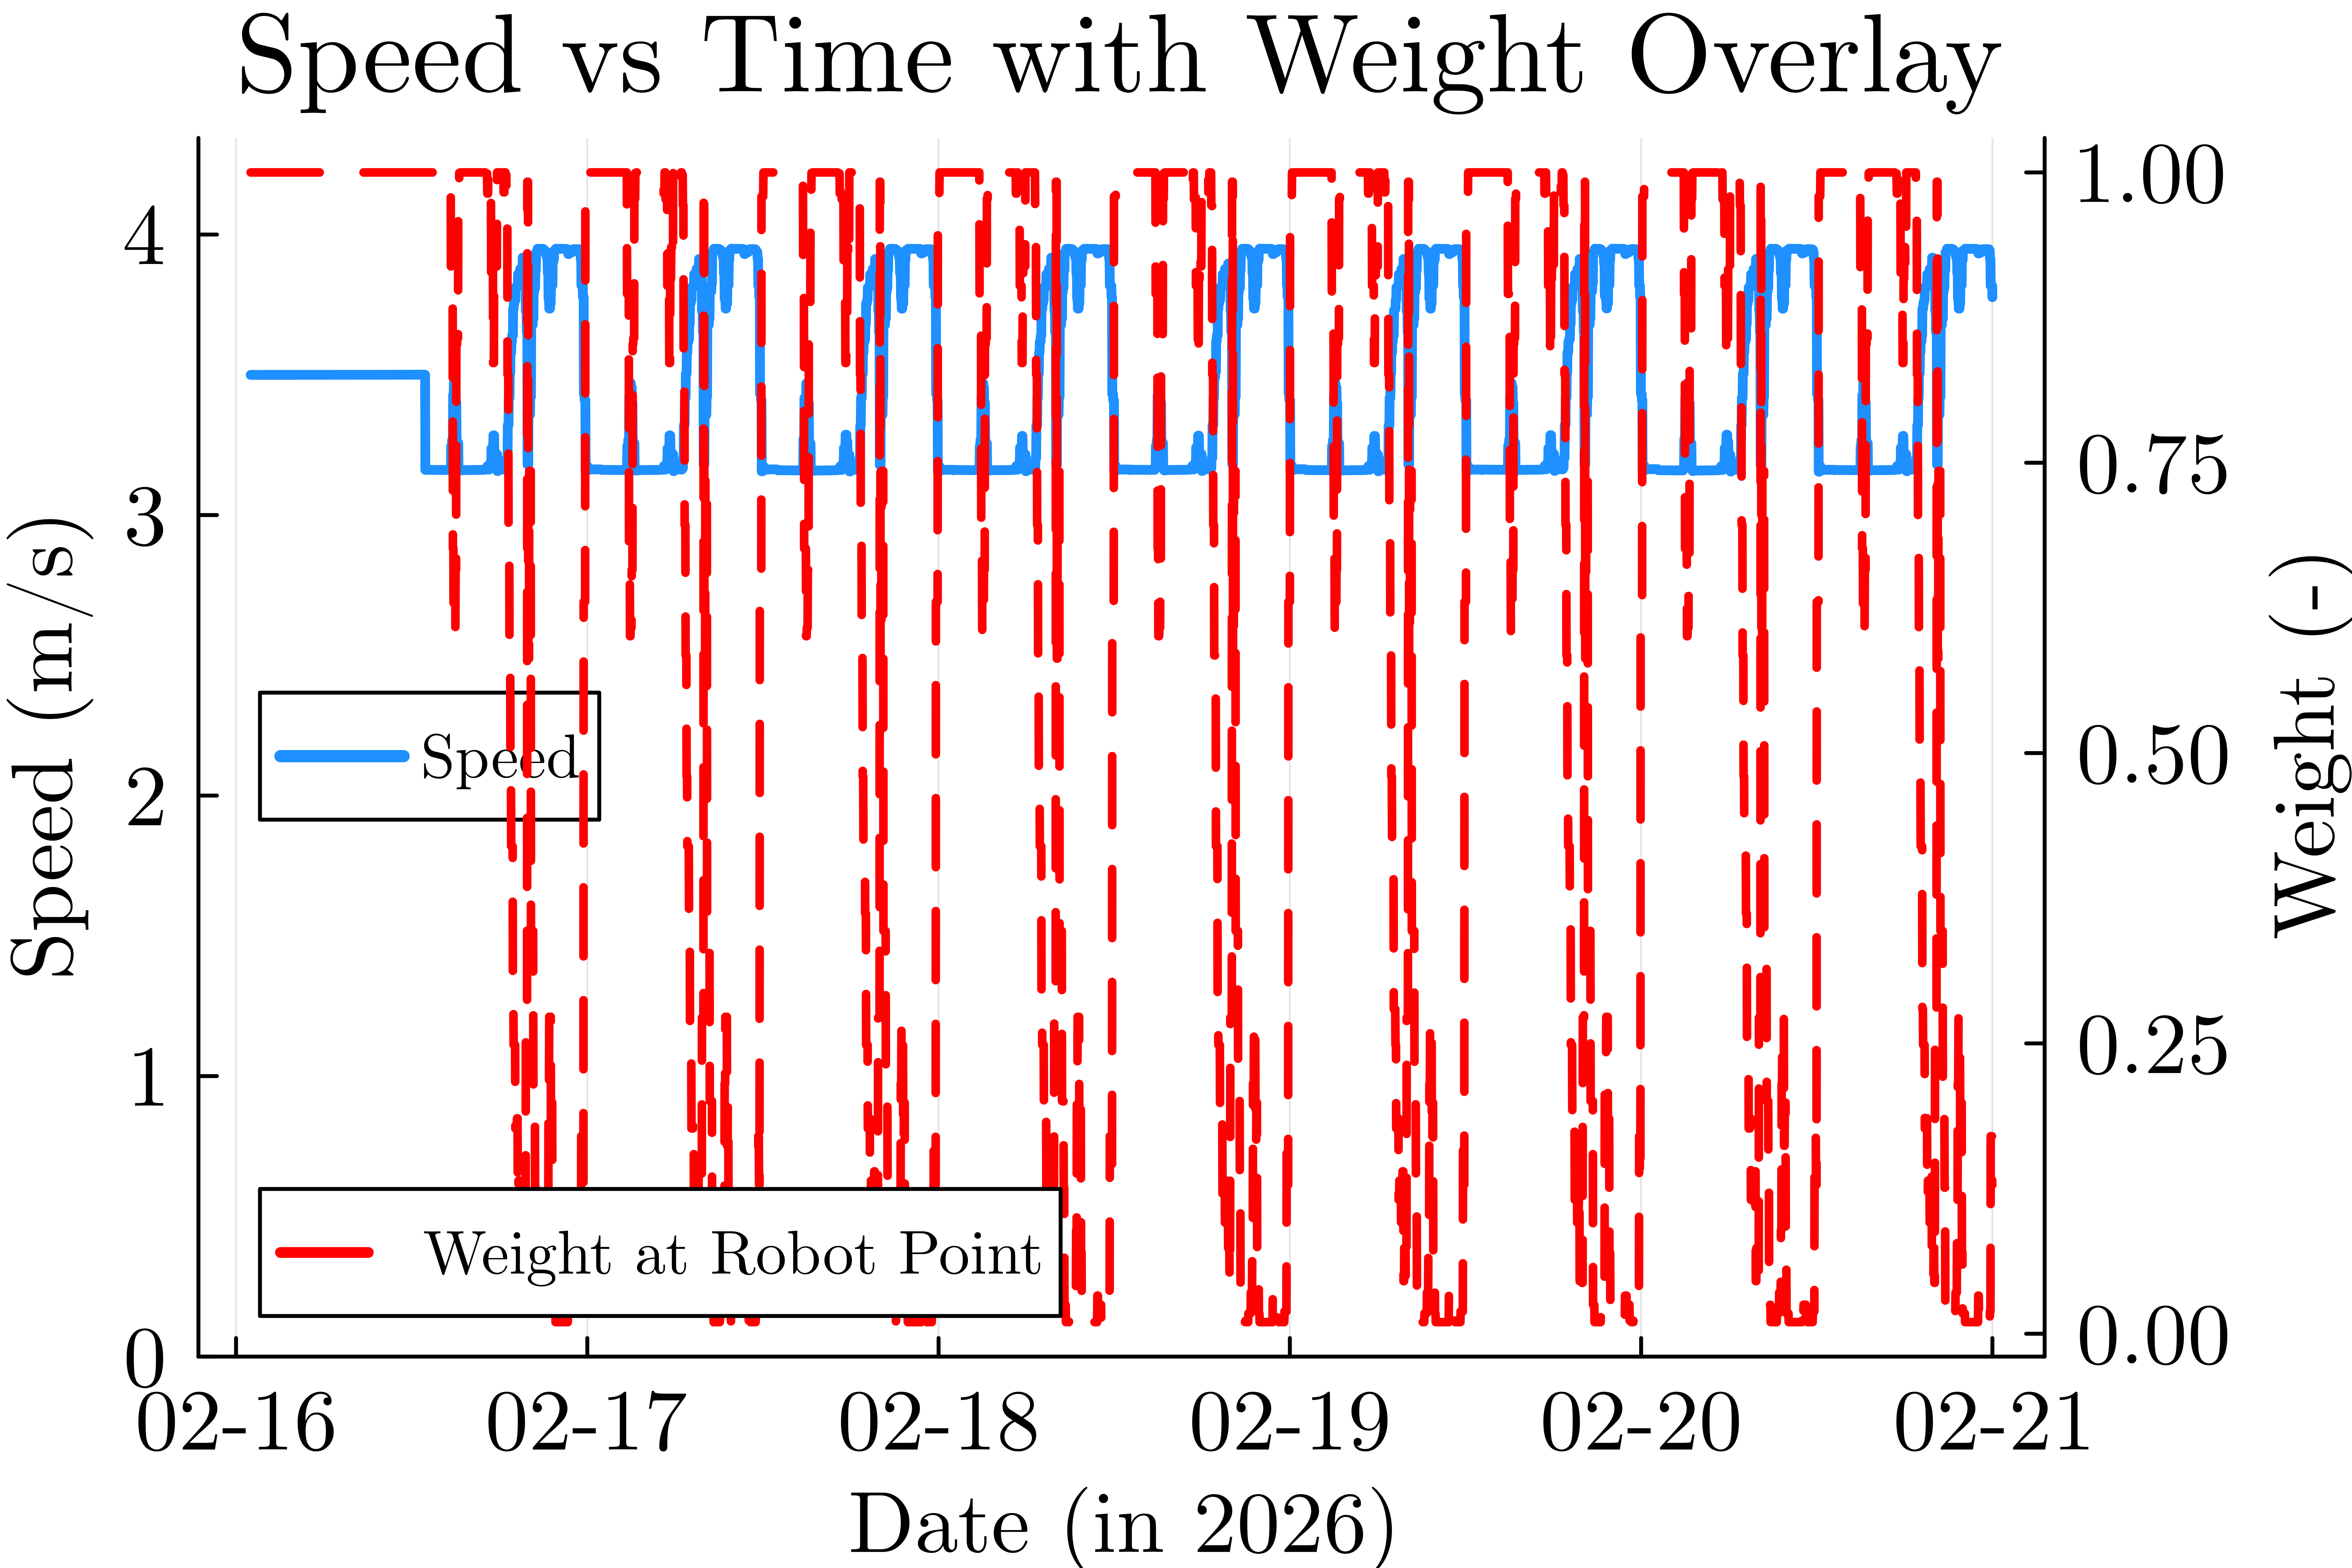

In [54]:
nsteps = length(sim_times)
robot_point_idx = Vector{Int}(undef, nsteps)
weight_at_robot = Vector{Float64}(undef, nsteps)

for k in 1:nsteps
    d2 = (lon_path .- lon_hist[k]).^2 .+ (lat_path .- lat_hist[k]).^2
    idx = argmin(d2)
    robot_point_idx[k] = idx
    weight_at_robot[k] = weights_history[idx, k]
end

daily_dates = collect(Date(sim_times[1]):Day(1):Date(sim_times[end]))
daily_ticks = DateTime.(daily_dates)
daily_labels = Dates.format.(daily_dates, dateformat"mm-dd")  # month-day only

p = plot(
    sim_times, speed_hist;
    lw = 2.5, lc = :dodgerblue,
    xlabel = "Date (in 2026)",
    ylabel = "Speed (m/s)",
    title = "Speed vs Time with Weight Overlay",
    label = "Speed",
    framestyle = :box,
    grid = true,
    legend = :left,
    ylims = (0, maximum(speed_hist) * 1.1),
    xticks = (daily_ticks, daily_labels)
)

plot!(
    twinx(), sim_times, weight_at_robot;
    lw = 2.2, lc = :crimson, ls = :dash,
    ylabel = "Weight (-)",
    label = "Weight at Robot Point"
)
plot!(dpi=1200)

savefig(p, "temp_figs/$(tag)_weight_overlay.png")
plot!()
